In [2]:
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from ctf_dataset.load import create_wrapped_dataset

In [3]:
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data_v1')
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual_v2.hdf5")

sns.set(context='notebook', style='white')
palette = sns.color_palette(['.65', 'darkgoldenrod'])

In [4]:
def teammate_decoding(train_lstms, test_lstms, train_targets, test_targets, lag=None):
    
    # Expand multioutput targets if needed
    if train_targets.ndim < 3:
        train_targets = train_targets[..., np.newaxis]
        test_targets = test_targets[..., np.newaxis]
    n_targets = train_targets.shape[-1]

    # Multioutput regression model for teammate
    model = MultiOutputRegressor(LinearRegression())
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])

    if not lag or lag == 0:
        pass

    elif lag > 0:
        train_lstms = train_lstms[..., :-lag, :]
        train_targets = train_targets[..., lag:, :]
        test_lstms = test_lstms[..., :-lag, :]
        test_targets = test_targets[..., lag:, :]

    elif lag < 0:
        train_lstms = train_lstms[..., -lag:, :]
        train_targets = train_targets[..., :lag, :]
        test_lstms = test_lstms[..., -lag:, :]
        test_targets = test_targets[..., :lag, :]
        
    # Split and stack runs (will need another split/stack for repeats)
    train_lstms = np.concatenate(np.split(train_lstms, n_maps - 1, axis=0), axis=1)[0]
    train_targets = np.concatenate(np.split(train_targets, n_maps - 1, axis=0), axis=1)[0]

    # Fit scaler and regression pipeline and predict
    pipeline.fit(train_lstms, train_targets)
    pred_targets = pipeline.predict(test_lstms)

    # Compute balanced accuracy scores per target
    target_scores = []
    for t in np.arange(n_targets):
        target_scores.append(pearsonr(test_targets[:, t], pred_targets[:, t])[0])
    
    return target_scores

In [5]:
def teammate_decoding_cv(lstms, targets, lag=None, n_splits=5):
    n_targets = targets.shape[-1]
    cv = KFold(n_splits=n_splits)

    # Multioutput regression model for teammate
    model = MultiOutputRegressor(LinearRegression())
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])

    scores = []
    for f, (train, test) in enumerate(cv.split(lstms)):

        if not lag or lag == 0:
            lstms_train = lstms[train]
            targets_train = targets[train]
            lstms_test = lstms[test]
            targets_test = targets[test]
            
        elif lag > 0:
            lstms_train = lstms[train][:-lag]
            targets_train = targets[train][lag:]
            lstms_test = lstms[test][:-lag]
            targets_test = targets[test][lag:]

        elif lag < 0:
            lstms_train = lstms[train][-lag:]
            targets_train = targets[train][:lag]
            lstms_test = lstms[test][-lag:]
            targets_test = targets[test][:lag]

        # Fit scaler and regression pipeline and predict
        pipeline.fit(lstms_train, targets_train)
        targets_pred = pipeline.predict(lstms_test)

        # Compute balanced accuracy scores per target
        target_scores = []
        for t in np.arange(n_targets):
            target_scores.append(pearsonr(targets_test[:, t], targets_pred[:, t])[0])
        scores.append(target_scores)
        print(f"Finished fold {f}")
    
    return scores

In [6]:
def teammate_residual(own_targets, teammate_targets):
    n_matches = own_targets.shape[0]
    residual_targets = []
    for match_id in np.arange(n_matches):
        player_match = own_targets[match_id]
        teammate_match = teammate_targets[match_id]
        x = np.linalg.lstsq(player_match[:, np.newaxis],
                            teammate_match, rcond=None)[0]
        teammate_residual = (teammate_match -
                             np.dot(player_match[:, np.newaxis], x))
        residual_targets.append(teammate_residual)
    teammate_residuals = np.stack(residual_targets, axis=0)
    return teammate_residuals

In [59]:
action_labels = {'look left/right': [0., 1., 2., 3., 4.],
                 'look up/down': [0., 1., 2.],
                 'strafe left/right': [0., 1., 2.],
                 'move backward/forward': [0., 1., 2.],
                 'fire or switch': [0., 1., 2., 3.],
                 'jump': [0., 1.]}

# Function for expanding 6 action channels into 20 subactions
def expand_action(action, subaction_labels=None):
    
    if not subaction_labels:
        subaction_labels = np.unique(action)
                
    subactions = np.zeros((action.shape +
                           (len(subaction_labels),)))
    for s in subaction_labels:
        subactions[..., int(s)][action == s] = 1
            
    return subactions

In [80]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

In [ ]:
# Load train/test PCA folds

player_label = 'action'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]

#action_label, action_id = 'move backward/forward', 3
action_label, action_id = 'strafe left/right', 2
subaction_labels = action_labels[action_label]
player_stack = expand_action(
    player_stack[..., action_id], subaction_labels=subaction_labels)

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_i in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_i, :, 0],
                         'teammate': player_stack[train_maps, player_teammate[player_i], :, 0],
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_i]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_i, :, 0],
                        'teammate': player_stack[test_map, player_teammate[player_i], :, 0],
                        'opponents': player_stack[test_map, player_opponents[player_i], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_i, :, :],
                                               test_lstms[..., player_i, :, :],
                                               train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_i] * len(scores))
                    print(f"player {player_i} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{action_label.split(" ")[0]}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.036 (test map 0)
player 0 player prediction lag 75 r = 0.057 (test map 0)
player 0 player prediction lag 15 r = 0.123 (test map 0)
player 0 player prediction lag 0 r = 0.518 (test map 0)
player 0 player prediction lag -15 r = 0.245 (test map 0)
player 0 player prediction lag -75 r = 0.099 (test map 0)
player 0 player prediction lag -150 r = -0.019 (test map 0)
player 0 teammate prediction lag 150 r = -0.005 (test map 0)
player 0 teammate prediction lag 75 r = 0.043 (test map 0)
player 0 teammate prediction lag 15 r = 0.106 (test map 0)
player 0 teammate prediction lag 0 r = 0.164 (test map 0)
player 0 teammate prediction lag -15 r = 0.134 (test map 0)
player 0 teammate prediction lag -75 r = 0.090 (test map 0)
player 0 teammate prediction lag -150 r = 0.018 (test map 0)
player 0 opponents prediction lag 150 r = 0.015 (test map 0)
player 0 opponents prediction lag 75 r = 0.002 (test map 0)
player 0 opponents prediction lag 15 r = 0.072 (test map 

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'player_from_opponent_base_xy_distance'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player_stack = player_stack[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id, :, 0],
                         'teammate': player_stack[train_maps, player_teammate[player_id], :, 0],
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_id]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id, :, 0],
                        'teammate': player_stack[test_map, player_teammate[player_id], :, 0],
                        'opponents': player_stack[test_map, player_opponents[player_id], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                              test_lstms[..., player_id, :, :],
                                              train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.247 (test map 0)
player 0 player prediction lag 75 r = 0.617 (test map 0)
player 0 player prediction lag 15 r = 0.942 (test map 0)
player 0 player prediction lag 0 r = 0.968 (test map 0)
player 0 player prediction lag -15 r = 0.935 (test map 0)
player 0 player prediction lag -75 r = 0.445 (test map 0)
player 0 player prediction lag -150 r = 0.051 (test map 0)
player 0 teammate prediction lag 150 r = 0.240 (test map 0)
player 0 teammate prediction lag 75 r = 0.568 (test map 0)
player 0 teammate prediction lag 15 r = 0.815 (test map 0)
player 0 teammate prediction lag 0 r = 0.823 (test map 0)
player 0 teammate prediction lag -15 r = 0.789 (test map 0)
player 0 teammate prediction lag -75 r = 0.459 (test map 0)
player 0 teammate prediction lag -150 r = 0.111 (test map 0)
player 0 opponents prediction lag 150 r = 0.064 (test map 0)
player 0 opponents prediction lag 75 r = 0.335 (test map 0)
player 0 opponents prediction lag 15 r = 0.561 (test map 0)

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'player_from_opponent_base_xy_distance'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player_stack = player_stack[..., :2]

opponent_label = 'player_from_own_base_xy_distance'
opponent_stack = wrap_f[f'map/matchup/repeat/player/time/{opponent_label}'][map_id, matchup_id, repeat_id, player_id]
opponent_stack = opponent_stack[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id, :, 0],
                         'teammate': player_stack[train_maps, player_teammate[player_id], :, 0],
                         'opponents': np.moveaxis(opponent_stack[train_maps][
                             :, player_opponents[player_id]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id, :, 0],
                        'teammate': player_stack[test_map, player_teammate[player_id], :, 0],
                        'opponents': opponent_stack[test_map, player_opponents[player_id], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                              test_lstms[..., player_id, :, :],
                                              train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{player_label}-alt_matchup-{matchup_id}_results.csv', index=False)

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'player_from_own_base_xy_distance'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player_stack = player_stack[..., :2]

opponent_label = 'player_from_opponent_base_xy_distance'
opponent_stack = wrap_f[f'map/matchup/repeat/player/time/{opponent_label}'][map_id, matchup_id, repeat_id, player_id]
opponent_stack = opponent_stack[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id, :, 0],
                         'teammate': player_stack[train_maps, player_teammate[player_id], :, 0],
                         'opponents': np.moveaxis(opponent_stack[train_maps][
                             :, player_opponents[player_id]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id, :, 0],
                        'teammate': player_stack[test_map, player_teammate[player_id], :, 0],
                        'opponents': opponent_stack[test_map, player_opponents[player_id], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                              test_lstms[..., player_id, :, :],
                                              train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{player_label}-alt_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.259 (test map 0)
player 0 player prediction lag 75 r = 0.621 (test map 0)
player 0 player prediction lag 15 r = 0.939 (test map 0)
player 0 player prediction lag 0 r = 0.966 (test map 0)
player 0 player prediction lag -15 r = 0.936 (test map 0)
player 0 player prediction lag -75 r = 0.422 (test map 0)
player 0 player prediction lag -150 r = 0.057 (test map 0)
player 0 teammate prediction lag 150 r = 0.243 (test map 0)
player 0 teammate prediction lag 75 r = 0.579 (test map 0)
player 0 teammate prediction lag 15 r = 0.824 (test map 0)
player 0 teammate prediction lag 0 r = 0.826 (test map 0)
player 0 teammate prediction lag -15 r = 0.790 (test map 0)
player 0 teammate prediction lag -75 r = 0.457 (test map 0)
player 0 teammate prediction lag -150 r = 0.136 (test map 0)
player 0 opponents prediction lag 150 r = 0.064 (test map 0)
player 0 opponents prediction lag 75 r = 0.335 (test map 0)
player 0 opponents prediction lag 15 r = 0.561 (test map 0)

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'health'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player_stack = player_stack[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id, :, 0],
                         'teammate': player_stack[train_maps, player_teammate[player_id], :, 0],
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_id]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id, :, 0],
                        'teammate': player_stack[test_map, player_teammate[player_id], :, 0],
                        'opponents': player_stack[test_map, player_opponents[player_id], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                              test_lstms[..., player_id, :, :],
                                              train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.065 (test map 0)
player 0 player prediction lag 75 r = 0.178 (test map 0)
player 0 player prediction lag 15 r = 0.861 (test map 0)
player 0 player prediction lag 0 r = 0.949 (test map 0)
player 0 player prediction lag -15 r = 0.905 (test map 0)
player 0 player prediction lag -75 r = 0.457 (test map 0)
player 0 player prediction lag -150 r = 0.350 (test map 0)
player 0 teammate prediction lag 150 r = -0.019 (test map 0)
player 0 teammate prediction lag 75 r = 0.147 (test map 0)
player 0 teammate prediction lag 15 r = 0.455 (test map 0)
player 0 teammate prediction lag 0 r = 0.454 (test map 0)
player 0 teammate prediction lag -15 r = 0.464 (test map 0)
player 0 teammate prediction lag -75 r = 0.403 (test map 0)
player 0 teammate prediction lag -150 r = 0.166 (test map 0)
player 0 opponents prediction lag 150 r = -0.064 (test map 0)
player 0 opponents prediction lag 75 r = 0.196 (test map 0)
player 0 opponents prediction lag 15 r = 0.462 (test map 

In [39]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'position'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player_stack = player_stack[..., :2]

In [103]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'position'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][
    map_id, matchup_id, repeat_id, player_id].astype(np.float32)

# Square position???
player_stack = player_stack[..., :2] #** 2

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in [0]:#np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id],
                         'teammate': player_stack[train_maps, player_teammate[player_id]],
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_id]], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id],
                        'teammate': player_stack[test_map, player_teammate[player_id]],
                        'opponents': player_stack[test_map, player_opponents[player_id]]}

        for target_label in ['player']:#train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in [0]:#lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                               test_lstms[..., player_id, :, :],
                                               train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
                    print(scores)
        
scores_df = pd.DataFrame(lag_scores)
#scores_df.to_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 0 r = 0.002 (test map 0)
[0.43173049788502493, -0.42799002877686826]
player 1 player prediction lag 0 r = 0.113 (test map 0)
[0.36965867740232844, -0.1436111399396443]
player 2 player prediction lag 0 r = 0.029 (test map 0)
[0.3268241779116515, -0.26831526912494064]
player 3 player prediction lag 0 r = -0.014 (test map 0)
[0.5178705067187012, -0.5456293655591062]


In [88]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'direction'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][
    map_id, matchup_id, repeat_id, player_id].astype(np.float32)
player_stack = player_stack[..., :2]

#player_stack = np.concatenate((np.sin(np.radians(player_stack)),
#                               np.cos(np.radians(player_stack))),
#                                   axis=-1)

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id],
                         'teammate': player_stack[train_maps, player_teammate[player_id]],
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_id]], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id],
                        'teammate': player_stack[test_map, player_teammate[player_id]],
                        'opponents': player_stack[test_map, player_opponents[player_id]]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in [0]:#lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                               test_lstms[..., player_id, :, :],
                                               train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
                    raise
        
scores_df = pd.DataFrame(lag_scores)
#scores_df.to_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 0 r = -0.001 (test map 0)


RuntimeError: No active exception to reraise

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'position'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][
    map_id, matchup_id, repeat_id, player_id].astype(np.float32)

# Square position???
player_stack = player_stack[..., :2] ** 2

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id],
                         'teammate': player_stack[train_maps, player_teammate[player_id]],
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_id]], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id],
                        'teammate': player_stack[test_map, player_teammate[player_id]],
                        'opponents': player_stack[test_map, player_opponents[player_id]]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                               test_lstms[..., player_id, :, :],
                                               train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
#scores_df.to_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv', index=False)

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'player_from_opponent_flag_xy_distance'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player_stack = player_stack[..., :2]

opponent_label = 'player_from_own_flag_xy_distance'
opponent_stack = wrap_f[f'map/matchup/repeat/player/time/{opponent_label}'][map_id, matchup_id, repeat_id, player_id]
opponent_stack = opponent_stack[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id, :, 0],
                         'teammate': player_stack[train_maps, player_teammate[player_id], :, 0],
                         'opponents': np.moveaxis(opponent_stack[train_maps][
                             :, player_opponents[player_id]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id, :, 0],
                        'teammate': player_stack[test_map, player_teammate[player_id], :, 0],
                        'opponents': opponent_stack[test_map, player_opponents[player_id], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                              test_lstms[..., player_id, :, :],
                                              train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{player_label}-alt_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.082 (test map 0)
player 0 player prediction lag 75 r = 0.282 (test map 0)
player 0 player prediction lag 15 r = 0.765 (test map 0)
player 0 player prediction lag 0 r = 0.877 (test map 0)
player 0 player prediction lag -15 r = 0.844 (test map 0)
player 0 player prediction lag -75 r = 0.550 (test map 0)
player 0 player prediction lag -150 r = 0.309 (test map 0)
player 0 teammate prediction lag 150 r = 0.014 (test map 0)
player 0 teammate prediction lag 75 r = 0.248 (test map 0)
player 0 teammate prediction lag 15 r = 0.642 (test map 0)
player 0 teammate prediction lag 0 r = 0.777 (test map 0)
player 0 teammate prediction lag -15 r = 0.755 (test map 0)
player 0 teammate prediction lag -75 r = 0.401 (test map 0)
player 0 teammate prediction lag -150 r = 0.216 (test map 0)
player 0 opponents prediction lag 150 r = 0.002 (test map 0)
player 0 opponents prediction lag 75 r = 0.175 (test map 0)
player 0 opponents prediction lag 15 r = 0.320 (test map 0)

In [351]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'value'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player_stack = player_stack[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'player': player_stack[train_maps, player_id, :, 0],
                         'teammate': player_stack[train_maps, player_teammate[player_id], :, 0],
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_id]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id, :, 0],
                        'teammate': player_stack[test_map, player_teammate[player_id], :, 0],
                        'opponents': player_stack[test_map, player_opponents[player_id], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                              test_lstms[..., player_id, :, :],
                                              train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.130 (test map 0)
player 0 player prediction lag 75 r = 0.474 (test map 0)
player 0 player prediction lag 15 r = 0.804 (test map 0)
player 0 player prediction lag 0 r = 0.966 (test map 0)
player 0 player prediction lag -15 r = 0.850 (test map 0)
player 0 player prediction lag -75 r = 0.475 (test map 0)
player 0 player prediction lag -150 r = 0.180 (test map 0)
player 0 teammate prediction lag 150 r = 0.108 (test map 0)
player 0 teammate prediction lag 75 r = 0.363 (test map 0)
player 0 teammate prediction lag 15 r = 0.633 (test map 0)
player 0 teammate prediction lag 0 r = 0.768 (test map 0)
player 0 teammate prediction lag -15 r = 0.759 (test map 0)
player 0 teammate prediction lag -75 r = 0.508 (test map 0)
player 0 teammate prediction lag -150 r = 0.071 (test map 0)
player 0 opponents prediction lag 150 r = -0.041 (test map 0)
player 0 opponents prediction lag 75 r = 0.188 (test map 0)
player 0 opponents prediction lag 15 r = 0.465 (test map 0

In [ ]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'reward'
player_stack = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][
    map_id, matchup_id, repeat_id, player_id].astype('float64')
player_stack = player_stack[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'test map': [], 'target': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    train_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    test_lstms = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    train_lstms = np.stack(np.split(np.stack(np.split(
        train_lstms, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    test_lstms = np.stack(np.split(test_lstms, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        
        train_residual = teammate_residual(
            player_stack[train_maps, player_id, :, 0],
            player_stack[train_maps, player_teammate[player_id], :, 0])
        test_residual = teammate_residual(
            player_stack[test_map, player_id, :, 0][np.newaxis, ...],
            player_stack[test_map, player_teammate[player_id], :, 0][np.newaxis, ...])[0]
        
        train_targets = {'player': player_stack[train_maps, player_id, :, 0],
                         'teammate': train_residual,
                         'opponents': np.moveaxis(player_stack[train_maps][
                             :, player_opponents[player_id]][..., 0], 1, 0)}
        test_targets = {'player': player_stack[test_map, player_id, :, 0],
                        'teammate': test_residual,
                        'opponents': player_stack[test_map, player_opponents[player_id], :, 0]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]

            for train_target, test_target in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = teammate_decoding(train_lstms[..., player_id, :, :],
                                              test_lstms[..., player_id, :, :],
                                              train_target, test_target, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = -0.006 (test map 0)
player 0 player prediction lag 75 r = 0.055 (test map 0)
player 0 player prediction lag 15 r = 0.140 (test map 0)
player 0 player prediction lag 0 r = 0.365 (test map 0)
player 0 player prediction lag -15 r = 0.162 (test map 0)
player 0 player prediction lag -75 r = 0.061 (test map 0)
player 0 player prediction lag -150 r = 0.040 (test map 0)
player 0 teammate prediction lag 150 r = 0.013 (test map 0)
player 0 teammate prediction lag 75 r = 0.049 (test map 0)
player 0 teammate prediction lag 15 r = 0.095 (test map 0)
player 0 teammate prediction lag 0 r = 0.150 (test map 0)
player 0 teammate prediction lag -15 r = 0.135 (test map 0)
player 0 teammate prediction lag -75 r = 0.089 (test map 0)
player 0 teammate prediction lag -150 r = 0.037 (test map 0)
player 0 opponents prediction lag 150 r = -0.016 (test map 0)
player 0 opponents prediction lag 75 r = 0.021 (test map 0)
player 0 opponents prediction lag 15 r = 0.048 (test map 

In [28]:
a = scores_df[(scores_df['target'] == 'player') &
          (scores_df['lag'] == 0) &
          (scores_df['player'] == 1)]
print(a['score'].min(), a['score'].max(), a['score'].mean())
a

-0.5732783099920236 0.3764905580080629 -0.04245258112608094


,score,lag,test map,target,player
31,0.369659,0,0,player,1
143,0.309365,0,1,player,1
255,0.147742,0,2,player,1
367,0.139019,0,3,player,1
479,0.372542,0,4,player,1
591,-0.276763,0,5,player,1
703,-0.516611,0,6,player,1
815,-0.198176,0,7,player,1
927,0.294963,0,8,player,1
1039,0.222097,0,9,player,1


In [34]:
a = scores_df[(scores_df['target'] == 'player') &
          (scores_df['lag'] == 0) &
          (scores_df['test map'] == 5)]
print(a['score'].min(), a['score'].max(), a['score'].mean())
a

-0.4754151742859759 -0.27676287999268295 -0.3962747966328559


,score,lag,test map,target,player
563,-0.413371,0,5,player,0
591,-0.276763,0,5,player,1
619,-0.475415,0,5,player,2
647,-0.419550,0,5,player,3


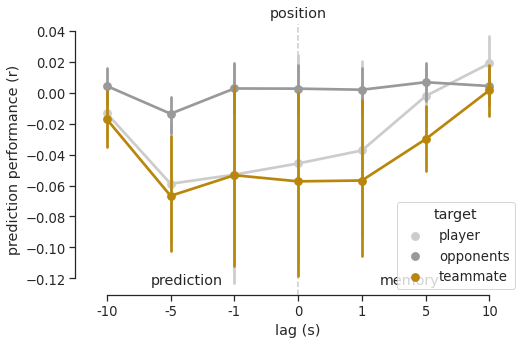

In [20]:
#player_label = 'player_from_own_base_xy_distance'
matchup_id = 0
player_label = 'position'
scores_df = pd.read_csv(f'results/decoding-cvpca_{player_label}_matchup-{matchup_id}_results.csv')

sns.set(style='ticks', font_scale=1.2)
palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate']) 
ax.set(xlabel='lag (s)', ylabel='prediction performance (r)',
       title=player_label)#, ylim=(-.05, 1.05))
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
sns.despine(trim=True)
#plt.savefig('figures/decoding_own_base_distance.png', bbox_inches='tight', transparent=True, dpi=300)

In [14]:
# Load pre-saved PCA-reduced data for all maps (one repeat)
matchup_id = 0
repeat_id = 0

n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_pcs = 142

lstms_pca = []
for map_id in np.arange(n_maps):
    lstms_pca.append(np.load(f'results/lstms-pca_matchup-{matchup_id}'
                             f'_map-{map_id}_repeat-{repeat_id}.npy')[..., :n_pcs])
    #print(f'Finished loading map {map_id}')
lstms_pca = np.stack(lstms_pca, axis=0)

lstms_stack = np.squeeze(np.concatenate(np.split(lstms_pca, 32, axis=0), axis=2))
print(lstms_stack.shape)

(4, 144032, 142)


In [7]:
# Load pre-saved PCA-reduced data for all maps (one repeat)
matchup_id = 0
repeat_id = 0

lstms_pca = []
for map_id in np.arange(n_maps):
    lstms_pca.append(np.load(f'results/lstms-pca_matchup-{matchup_id}'
                             f'_map-{map_id}_repeat-{repeat_id}.npy')[..., :n_pcs])
lstms_pca = np.stack(lstms_pca, axis=0)

In [435]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 5

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'position'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': [], 'map': []}
for map_id in np.arange(n_maps):
    for player_id in [0]:
        
        targets = {'player': player[map_id, player_id],
                   'teammate': player[map_id, player_teammate[player_id]],
                   'opponents': player[map_id, player_opponents[player_id]]}
        
        for target_label in targets.keys():

            if target_label is not 'opponents':
                target_stack = np.expand_dims(targets[target_label], axis=0)
            else:
                target_stack = targets[target_label]
            for target in target_stack:
                for lag in lags.keys():
                    scores = teammate_decoding(lstms_pca[map_id, player_id], target,
                                               lag=lag, n_splits=n_splits)
                    lag_scores['score'].extend(np.mean(scores, axis=1))
                    lag_scores['lag'].extend([lags[lag]] * n_splits)
                    lag_scores['fold'].extend(np.arange(n_splits))
                    lag_scores['target'].extend([target_label] * n_splits)
                    lag_scores['player'].extend([player_id] * n_splits)
                    lag_scores['map'].extend([map_id] * n_splits)
                    print(f"Map {map_id} player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

Map 0 player 0 player prediction lag 150 r = 0.104
Map 0 player 0 player prediction lag 75 r = 0.260
Map 0 player 0 player prediction lag 15 r = 0.605
Map 0 player 0 player prediction lag 0 r = 0.693
Map 0 player 0 player prediction lag -15 r = 0.660
Map 0 player 0 player prediction lag -75 r = 0.108
Map 0 player 0 player prediction lag -150 r = 0.059
Map 0 player 0 teammate prediction lag 150 r = 0.085
Map 0 player 0 teammate prediction lag 75 r = 0.320
Map 0 player 0 teammate prediction lag 15 r = 0.563
Map 0 player 0 teammate prediction lag 0 r = 0.596
Map 0 player 0 teammate prediction lag -15 r = 0.544
Map 0 player 0 teammate prediction lag -75 r = 0.290
Map 0 player 0 teammate prediction lag -150 r = 0.055
Map 0 player 0 opponents prediction lag 150 r = -0.018
Map 0 player 0 opponents prediction lag 75 r = 0.212
Map 0 player 0 opponents prediction lag 15 r = 0.229
Map 0 player 0 opponents prediction lag 0 r = 0.280
Map 0 player 0 opponents prediction lag -15 r = 0.243
Map 0 playe

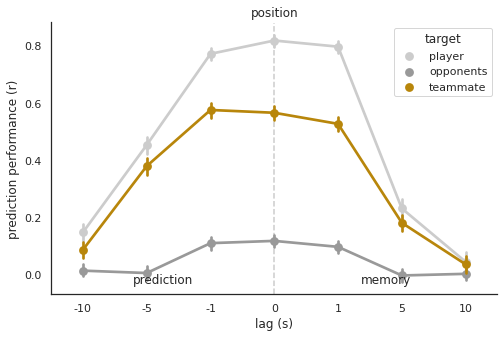

In [7]:
player_label = 'position'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate']) 
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title(player_label)
sns.despine()

In [ ]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_label = 'position'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

teammate_label = 'teammate_position'
teammate = wrap_f[f'map/matchup/repeat/player/time/{teammate_label}'][map_id, matchup_id, repeat_id, player_id]
teammate = teammate[..., :2]
teammate_stack = np.concatenate(np.split(teammate, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}
targets = {'player': player_stack, 'teammate': teammate_stack}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': []}
for player_id in np.arange(n_players):
    for target in targets.keys():
        for lag in lags.keys():
            scores = teammate_decoding(lstms_stack[player_id], targets[target][player_id],
                                       lag=lag, n_splits=n_splits)
            lag_scores['score'].extend(np.mean(scores, axis=1))
            lag_scores['lag'].extend([lags[lag]] * n_splits)
            lag_scores['fold'].extend(np.arange(n_splits))
            lag_scores['target'].extend([target] * n_splits)
            lag_scores['player'].extend([player_id] * n_splits)
            print(f"player {player_id} {target} prediction "
                  f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_teammate-{player_label}_matchup-{matchup_id}_results.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df, ax=ax, palette=palette)
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title(player_label)
sns.despine()

Finished fold 0
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 6
Finished fold 7
Finished fold 8
Finished fold 9
Finished fold 10
Finished fold 11
Finished fold 12
Finished fold 13
Finished fold 14
Finished fold 15
Finished fold 16
Finished fold 17
Finished fold 18
Finished fold 19
Finished fold 20
Finished fold 21
Finished fold 22
Finished fold 23
Finished fold 24
Finished fold 25
Finished fold 26
Finished fold 27
Finished fold 28
Finished fold 29
Finished fold 30
Finished fold 31
player 0 player prediction lag 150 r = -0.024
Finished fold 0
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 6
Finished fold 7
Finished fold 8
Finished fold 9
Finished fold 10
Finished fold 11
Finished fold 12
Finished fold 13
Finished fold 14
Finished fold 15
Finished fold 16
Finished fold 17
Finished fold 18
Finished fold 19
Finished fold 20
Finished fold 21
Finished fold 22
Finished fold 23
Finished fold 24
Finis

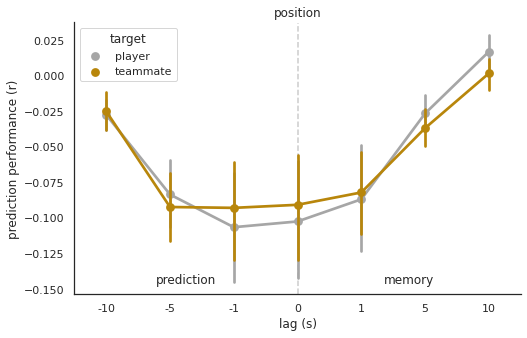

In [298]:
player_label = 'position'
scores_df = pd.read_csv(f'results/decoding_teammate-{player_label}_matchup-{matchup_id}_results.csv')

fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df, ax=ax, palette=palette)
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title(player_label)
sns.despine()

In [439]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 5

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'velocity'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': [], 'map': []}
for map_id in np.arange(n_maps):
    for player_id in [0]:
        
        targets = {'player': player[map_id, player_id],
                   'teammate': player[map_id, player_teammate[player_id]],
                   'opponents': player[map_id, player_opponents[player_id]]}
        
        for target_label in targets.keys():

            if target_label is not 'opponents':
                target_stack = np.expand_dims(targets[target_label], axis=0)
            else:
                target_stack = targets[target_label]
            for target in target_stack:
                for lag in lags.keys():
                    scores = teammate_decoding(lstms_pca[map_id, player_id], target,
                                               lag=lag, n_splits=n_splits)
                    lag_scores['score'].extend(np.mean(scores, axis=1))
                    lag_scores['lag'].extend([lags[lag]] * n_splits)
                    lag_scores['fold'].extend(np.arange(n_splits))
                    lag_scores['target'].extend([target_label] * n_splits)
                    lag_scores['player'].extend([player_id] * n_splits)
                    lag_scores['map'].extend([map_id] * n_splits)
                    print(f"Map {map_id} player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

Map 0 player 0 player prediction lag 150 r = 0.050
Map 0 player 0 player prediction lag 75 r = 0.111
Map 0 player 0 player prediction lag 15 r = 0.384
Map 0 player 0 player prediction lag 0 r = 0.522
Map 0 player 0 player prediction lag -15 r = 0.360
Map 0 player 0 player prediction lag -75 r = 0.102
Map 0 player 0 player prediction lag -150 r = -0.036
Map 0 player 0 teammate prediction lag 150 r = -0.001
Map 0 player 0 teammate prediction lag 75 r = 0.143
Map 0 player 0 teammate prediction lag 15 r = 0.322
Map 0 player 0 teammate prediction lag 0 r = 0.322
Map 0 player 0 teammate prediction lag -15 r = 0.280
Map 0 player 0 teammate prediction lag -75 r = 0.208
Map 0 player 0 teammate prediction lag -150 r = -0.011
Map 0 player 0 opponents prediction lag 150 r = -0.011
Map 0 player 0 opponents prediction lag 75 r = 0.044
Map 0 player 0 opponents prediction lag 15 r = 0.137
Map 0 player 0 opponents prediction lag 0 r = 0.157
Map 0 player 0 opponents prediction lag -15 r = 0.146
Map 0 pl

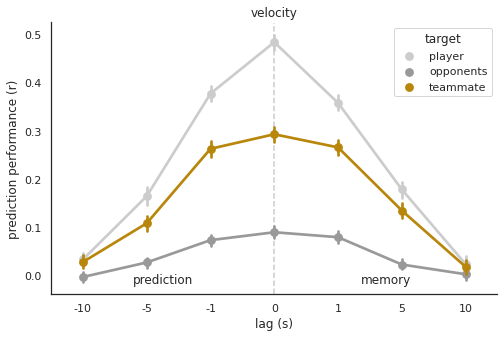

In [440]:
player_label = 'velocity'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate'])
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title(player_label)
sns.despine()

Map 0 player 0 player prediction lag 150 r = 0.050
Map 0 player 0 player prediction lag 75 r = 0.111
Map 0 player 0 player prediction lag 15 r = 0.384
Map 0 player 0 player prediction lag 0 r = 0.522
Map 0 player 0 player prediction lag -15 r = 0.360
Map 0 player 0 player prediction lag -75 r = 0.102
Map 0 player 0 player prediction lag -150 r = -0.036
Map 0 player 0 teammate prediction lag 150 r = -0.001
Map 0 player 0 teammate prediction lag 75 r = 0.143
Map 0 player 0 teammate prediction lag 15 r = 0.322
Map 0 player 0 teammate prediction lag 0 r = 0.322
Map 0 player 0 teammate prediction lag -15 r = 0.280
Map 0 player 0 teammate prediction lag -75 r = 0.208
Map 0 player 0 teammate prediction lag -150 r = -0.011
Map 1 player 0 player prediction lag 150 r = 0.110
Map 1 player 0 player prediction lag 75 r = 0.092
Map 1 player 0 player prediction lag 15 r = 0.329
Map 1 player 0 player prediction lag 0 r = 0.436
Map 1 player 0 player prediction lag -15 r = 0.257
Map 1 player 0 player pr

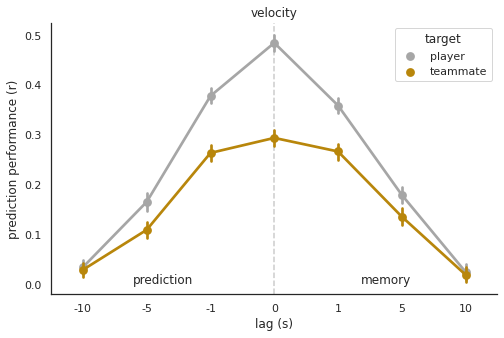

In [339]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 5

player_label = 'velocity'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]

teammate_label = 'teammate_velocity'
teammate = wrap_f[f'map/matchup/repeat/player/time/{teammate_label}'][map_id, matchup_id, repeat_id, player_id]
teammate = teammate[..., :2]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}
targets = {'player': player, 'teammate': teammate}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': [], 'map': []}
for map_id in np.arange(n_maps):
    for player_id in [0]:
        for target in targets.keys():
            for lag in lags.keys():
                scores = teammate_decoding(lstms_pca[map_id, player_id], targets[target][map_id, player_id],
                                           lag=lag, n_splits=n_splits)
                lag_scores['score'].extend(np.mean(scores, axis=1))
                lag_scores['lag'].extend([lags[lag]] * n_splits)
                lag_scores['fold'].extend(np.arange(n_splits))
                lag_scores['target'].extend([target] * n_splits)
                lag_scores['player'].extend([player_id] * n_splits)
                lag_scores['map'].extend([map_id] * n_splits)
                print(f"Map {map_id} player {player_id} {target} prediction "
                      f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_teammate-{player_label}_matchup-{matchup_id}_results.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df, ax=ax, palette=palette)
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title(player_label)
sns.despine()

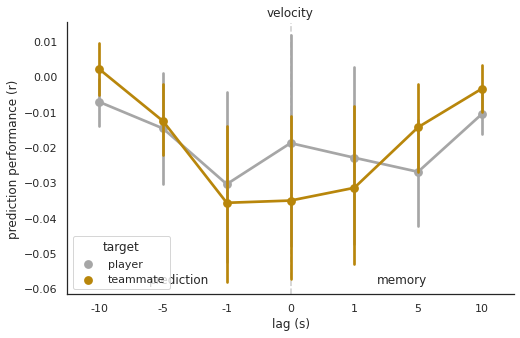

In [299]:
player_label = 'velocity'
scores_df = pd.read_csv(f'results/decoding_teammate-{player_label}_matchup-{matchup_id}_results.csv')

fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df, ax=ax, palette=palette)
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title(player_label)
sns.despine()

In [348]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)


lstms_pca = []
for map_id in np.arange(n_maps):
    lstms_pca.append(np.load(f'results/lstms-pca_matchup-{matchup_id}'
                             f'_map-{map_id}_repeat-{repeat_id}.npy')[..., :n_pcs])
    #print(f'Finished loading map {map_id}')
lstms_pca = np.stack(lstms_pca, axis=0)

lstms_stack = np.squeeze(np.concatenate(np.split(lstms_pca, 32, axis=0), axis=2))
print(lstms_stack.shape)

(4, 144032, 142)


In [350]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_labels = ['player_from_teammate_xy_distance',
                 'player_from_teammate_direction']     
player_label = player_labels[0]
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'player': []}
for player_id in np.arange(n_players):
    for lag in lags.keys():
        scores = teammate_decoding(lstms_stack[player_id], player_stack[player_id],
                                   lag=lag, n_splits=n_splits)
        lag_scores['score'].extend(np.mean(scores, axis=1))
        lag_scores['lag'].extend([lags[lag]] * n_splits)
        lag_scores['fold'].extend(np.arange(n_splits))
        lag_scores['player'].extend([player_id] * n_splits)
        print(f"player {player_id} {target} prediction "
              f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 teammate prediction lag 150 r = 0.095
player 0 teammate prediction lag 75 r = 0.392
player 0 teammate prediction lag 15 r = 0.720
player 0 teammate prediction lag 0 r = 0.792
player 0 teammate prediction lag -15 r = 0.718
player 0 teammate prediction lag -75 r = 0.251
player 0 teammate prediction lag -150 r = 0.114
player 1 teammate prediction lag 150 r = 0.095
player 1 teammate prediction lag 75 r = 0.393
player 1 teammate prediction lag 15 r = 0.730
player 1 teammate prediction lag 0 r = 0.798
player 1 teammate prediction lag -15 r = 0.723
player 1 teammate prediction lag -75 r = 0.285
player 1 teammate prediction lag -150 r = 0.119
player 2 teammate prediction lag 150 r = 0.089
player 2 teammate prediction lag 75 r = 0.389
player 2 teammate prediction lag 15 r = 0.725
player 2 teammate prediction lag 0 r = 0.791
player 2 teammate prediction lag -15 r = 0.722
player 2 teammate prediction lag -75 r = 0.237
player 2 teammate prediction lag -150 r = 0.111
player 3 teammate pred

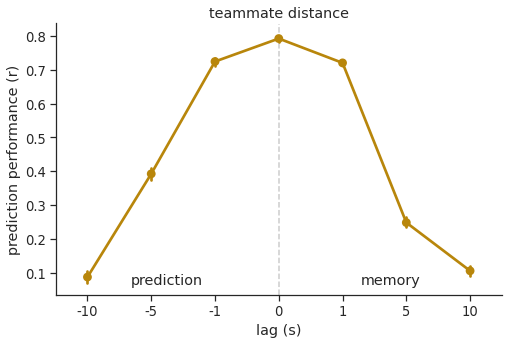

In [71]:
player_label = 'player_from_teammate_xy_distance'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

sns.set(style='ticks', font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', data=scores_df, ax=ax, color='darkgoldenrod')
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title('teammate distance')
sns.despine()
plt.savefig('figures/decoding_teammate_distance.png', bbox_inches='tight', transparent=True, dpi=300)

In [354]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_labels = ['player_from_teammate_xy_distance',
                 'player_from_teammate_direction']     
player_label = player_labels[1]
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'player': []}
for player_id in np.arange(n_players):
    for lag in lags.keys():
        scores = teammate_decoding(lstms_stack[player_id], player_stack[player_id],
                                   lag=lag, n_splits=n_splits)
        lag_scores['score'].extend(np.mean(scores, axis=1))
        lag_scores['lag'].extend([lags[lag]] * n_splits)
        lag_scores['fold'].extend(np.arange(n_splits))
        lag_scores['player'].extend([player_id] * n_splits)
        print(f"player {player_id} {target} prediction "
              f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 teammate prediction lag 150 r = 0.005
player 0 teammate prediction lag 75 r = -0.006
player 0 teammate prediction lag 15 r = -0.016
player 0 teammate prediction lag 0 r = -0.008
player 0 teammate prediction lag -15 r = -0.011
player 0 teammate prediction lag -75 r = -0.010
player 0 teammate prediction lag -150 r = 0.004
player 1 teammate prediction lag 150 r = -0.009
player 1 teammate prediction lag 75 r = -0.007
player 1 teammate prediction lag 15 r = -0.013
player 1 teammate prediction lag 0 r = -0.017
player 1 teammate prediction lag -15 r = -0.005
player 1 teammate prediction lag -75 r = -0.002
player 1 teammate prediction lag -150 r = 0.009
player 2 teammate prediction lag 150 r = -0.002
player 2 teammate prediction lag 75 r = -0.012
player 2 teammate prediction lag 15 r = -0.028
player 2 teammate prediction lag 0 r = -0.014
player 2 teammate prediction lag -15 r = -0.008
player 2 teammate prediction lag -75 r = -0.007
player 2 teammate prediction lag -150 r = -0.003
play

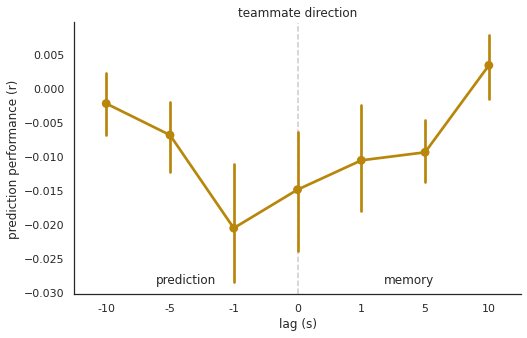

In [356]:
player_label = 'player_from_teammate_direction'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', data=scores_df, ax=ax, color='darkgoldenrod')
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title('teammate direction')
sns.despine()

In [413]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'player_from_opponent_base_xy_distance'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': []}
for player_id in [0]:
    
    targets = {'player': player_stack[player_id],
               'teammate': player_stack[player_teammate[player_id]],
               'opponents': player_stack[player_opponents[player_id]]}
    
    for target_label in targets.keys():
        if target_label is not 'opponents':
            target_stack = np.expand_dims(targets[target_label], axis=0)
        else:
            target_stack = targets[target_label]
        for target in target_stack:
            for lag in lags.keys():
                scores = teammate_decoding(lstms_stack[player_id], target,
                                           lag=lag, n_splits=n_splits)
                lag_scores['score'].extend(np.mean(scores, axis=1))
                lag_scores['lag'].extend([lags[lag]] * n_splits)
                lag_scores['fold'].extend(np.arange(n_splits))
                lag_scores['target'].extend([target_label] * n_splits)
                lag_scores['player'].extend([player_id] * n_splits)
                print(f"player {player_id} {target_label} prediction "
                      f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.346
player 0 player prediction lag 75 r = 0.728
player 0 player prediction lag 15 r = 0.955
player 0 player prediction lag 0 r = 0.975
player 0 player prediction lag -15 r = 0.946
player 0 player prediction lag -75 r = 0.514
player 0 player prediction lag -150 r = 0.174
player 0 teammate prediction lag 150 r = 0.305
player 0 teammate prediction lag 75 r = 0.673
player 0 teammate prediction lag 15 r = 0.843
player 0 teammate prediction lag 0 r = 0.829
player 0 teammate prediction lag -15 r = 0.785
player 0 teammate prediction lag -75 r = 0.417
player 0 teammate prediction lag -150 r = 0.141
player 0 opponents prediction lag 150 r = 0.012
player 0 opponents prediction lag 75 r = 0.172
player 0 opponents prediction lag 15 r = 0.344
player 0 opponents prediction lag 0 r = 0.354
player 0 opponents prediction lag -15 r = 0.325
player 0 opponents prediction lag -75 r = 0.147
player 0 opponents prediction lag -150 r = 0.041
player 0 opponents prediction

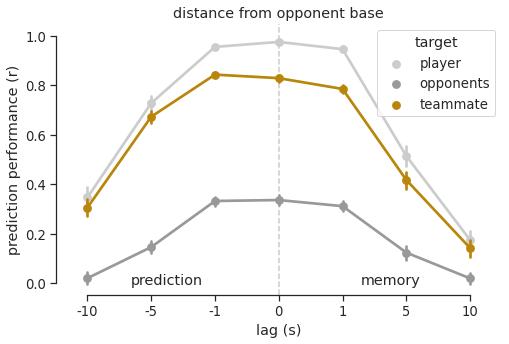

In [70]:
player_label = 'player_from_opponent_base_xy_distance'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

sns.set(style='ticks', font_scale=1.2)
palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate']) 
ax.set(xlabel='lag (s)', ylabel='prediction performance (r)',
       title='distance from opponent base', ylim=(-.05, 1.05))
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
sns.despine(trim=True)
plt.savefig('figures/decoding_distance_from_opponent_base.png', bbox_inches='tight', transparent=True, dpi=300)

In [423]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'player_from_opponent_base_xy_distance'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

opponent_label = 'player_from_own_base_xy_distance'
opponent = wrap_f[f'map/matchup/repeat/player/time/{opponent_label}'][map_id, matchup_id, repeat_id, player_id]
opponent = opponent[..., :2]
opponent_stack = np.concatenate(np.split(opponent, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': []}
for player_id in [0]:
    
    targets = {'player': player_stack[player_id],
               'teammate': player_stack[player_teammate[player_id]],
               'opponents': opponent_stack[player_opponents[player_id]]}
    
    for target_label in targets.keys():
        if target_label is not 'opponents':
            target_stack = np.expand_dims(targets[target_label], axis=0)
        else:
            target_stack = targets[target_label]
        for target in target_stack:
            for lag in lags.keys():
                scores = teammate_decoding(lstms_stack[player_id], target,
                                           lag=lag, n_splits=n_splits)
                lag_scores['score'].extend(np.mean(scores, axis=1))
                lag_scores['lag'].extend([lags[lag]] * n_splits)
                lag_scores['fold'].extend(np.arange(n_splits))
                lag_scores['target'].extend([target_label] * n_splits)
                lag_scores['player'].extend([player_id] * n_splits)
                print(f"player {player_id} {target_label} prediction "
                      f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.346
player 0 player prediction lag 75 r = 0.728
player 0 player prediction lag 15 r = 0.955
player 0 player prediction lag 0 r = 0.975
player 0 player prediction lag -15 r = 0.946
player 0 player prediction lag -75 r = 0.514
player 0 player prediction lag -150 r = 0.174
player 0 teammate prediction lag 150 r = 0.305
player 0 teammate prediction lag 75 r = 0.673
player 0 teammate prediction lag 15 r = 0.843
player 0 teammate prediction lag 0 r = 0.829
player 0 teammate prediction lag -15 r = 0.785
player 0 teammate prediction lag -75 r = 0.417
player 0 teammate prediction lag -150 r = 0.141
player 0 opponents prediction lag 150 r = 0.029
player 0 opponents prediction lag 75 r = 0.169
player 0 opponents prediction lag 15 r = 0.329
player 0 opponents prediction lag 0 r = 0.339
player 0 opponents prediction lag -15 r = 0.317
player 0 opponents prediction lag -75 r = 0.155
player 0 opponents prediction lag -150 r = 0.044
player 0 opponents prediction

In [9]:
player_label = 'player_from_opponent_base_xy_distance'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate'])
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title('distance from opponent base')
sns.despine()
plt.savefig('decoding_distance_from_opponent_base.png')

NameError: name 'matchup_id' is not defined

In [ ]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'health'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': []}
for player_id in [0]:
    
    targets = {'player': player_stack[player_id],
               'teammate': player_stack[player_teammate[player_id]],
               'opponents': player_stack[player_opponents[player_id]]}
    
    for target_label in targets.keys():
        if target_label is not 'opponents':
            target_stack = np.expand_dims(targets[target_label], axis=0)
        else:
            target_stack = targets[target_label]
        for target in target_stack:
            for lag in lags.keys():
                scores = teammate_decoding(lstms_stack[player_id], target,
                                           lag=lag, n_splits=n_splits)
                lag_scores['score'].extend(np.mean(scores, axis=1))
                lag_scores['lag'].extend([lags[lag]] * n_splits)
                lag_scores['fold'].extend(np.arange(n_splits))
                lag_scores['target'].extend([target_label] * n_splits)
                lag_scores['player'].extend([player_id] * n_splits)
                print(f"player {player_id} {target_label} prediction "
                      f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

player 0 player prediction lag 150 r = 0.055
player 0 player prediction lag 75 r = 0.310


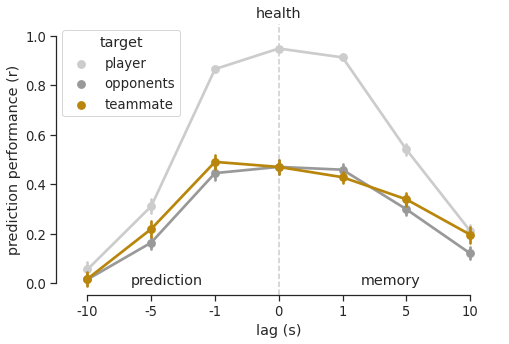

In [69]:
player_label = 'health'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

sns.set(style='ticks', font_scale=1.2)
palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate']) 
ax.set(xlabel='lag (s)', ylabel='prediction performance (r)',
       title='health', ylim=(-.05, 1.05))
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
sns.despine(trim=True)
plt.savefig('figures/decoding_health.png', bbox_inches='tight', transparent=True, dpi=300)

In [ ]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'teammate_is_alive'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': []}
for player_id in [0]:
    
    targets = {'player': player_stack[player_id],
               'teammate': player_stack[player_teammate[player_id]],
               'opponents': player_stack[player_opponents[player_id]]}
    
    for target_label in targets.keys():
        if target_label is not 'opponents':
            target_stack = np.expand_dims(targets[target_label], axis=0)
        else:
            target_stack = targets[target_label]
        for target in target_stack:
            for lag in lags.keys():
                scores = teammate_decoding(lstms_stack[player_id], target,
                                           lag=lag, n_splits=n_splits)
                lag_scores['score'].extend(np.mean(scores, axis=1))
                lag_scores['lag'].extend([lags[lag]] * n_splits)
                lag_scores['fold'].extend(np.arange(n_splits))
                lag_scores['target'].extend([target_label] * n_splits)
                lag_scores['player'].extend([player_id] * n_splits)
                print(f"player {player_id} {target_label} prediction "
                      f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

In [441]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

lstms_pca = []
for map_id in np.arange(n_maps):
    lstms_pca.append(np.load(f'results/lstms-pca_matchup-{matchup_id}'
                             f'_map-{map_id}_repeat-{repeat_id}.npy')[..., :n_pcs])
lstms_pca = np.stack(lstms_pca, axis=0)

lstms_stack = np.squeeze(np.concatenate(np.split(lstms_pca, 32, axis=0), axis=2))
print(lstms_stack.shape)

(4, 144032, 142)


In [474]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 2

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'lstms'

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': [], 'PC': []}
for player_id in [0]:
    
    targets = {'teammate': lstms_stack[player_teammate[player_id], :9002],
               'opponents': lstms_stack[player_opponents[player_id], :9002]}
    
    for target_label in targets.keys():
        if target_label is not 'opponents':
            target_stack = np.expand_dims(targets[target_label], axis=0)
        else:
            target_stack = targets[target_label]
        for target in target_stack:
            for lag in lags.keys():
                scores = np.array(teammate_decoding(lstms_stack[player_id, :9002], target,
                                                    lag=lag, n_splits=n_splits))
                for pc_id, score in enumerate(scores.T):
                    lag_scores['score'].extend(score)
                    lag_scores['lag'].extend([lags[lag]] * n_splits)
                    lag_scores['fold'].extend(np.arange(n_splits))
                    lag_scores['target'].extend([target_label] * n_splits)
                    lag_scores['player'].extend([player_id] * n_splits)
                    lag_scores['PC'].extend([pc_id] * n_splits)
                print(f"player {player_id} {target_label} prediction "
                      f"lag {lag} r = {np.mean(score):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
#scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

Finished fold 0
Finished fold 1
player 0 teammate prediction lag 150 r = -0.007
Finished fold 0
Finished fold 1
player 0 teammate prediction lag 75 r = 0.030
Finished fold 0
Finished fold 1
player 0 teammate prediction lag 15 r = 0.112
Finished fold 0
Finished fold 1
player 0 teammate prediction lag 0 r = 0.146
Finished fold 0
Finished fold 1
player 0 teammate prediction lag -15 r = 0.112
Finished fold 0
Finished fold 1
player 0 teammate prediction lag -75 r = -0.007
Finished fold 0
Finished fold 1
player 0 teammate prediction lag -150 r = 0.025
Finished fold 0
Finished fold 1
player 0 opponents prediction lag 150 r = 0.030
Finished fold 0
Finished fold 1
player 0 opponents prediction lag 75 r = -0.034
Finished fold 0
Finished fold 1
player 0 opponents prediction lag 15 r = 0.068
Finished fold 0
Finished fold 1
player 0 opponents prediction lag 0 r = 0.094
Finished fold 0
Finished fold 1
player 0 opponents prediction lag -15 r = 0.061
Finished fold 0
Finished fold 1
player 0 opponents 

In [54]:
player_label = 'lstms'
#scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['opponents', 'teammate'])
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title('LSTMs')
sns.despine()

FileNotFoundError: [Errno 2] No such file or directory: 'results/decoding_lstms_matchup-0_results.csv'

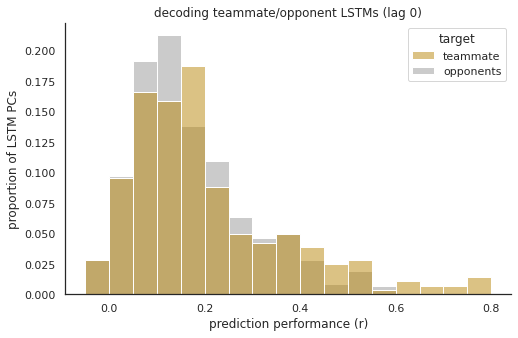

In [504]:
player_label = 'lstms'
#scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['darkgoldenrod', '.6'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(x='score', hue='target', stat='probability', common_norm=False, palette=palette,
             binwidth=0.05, binrange=(-.05, 0.8), data=scores_df[scores_df['lag'] == 0], ax=ax)
ax.set_xlabel('prediction performance (r)')
ax.set_ylabel('proportion of LSTM PCs')
ax.set_title('decoding teammate/opponent LSTMs (lag 0)')
sns.despine()

In [ ]:
### Scatter plot (color by number of PC) and landscape plot

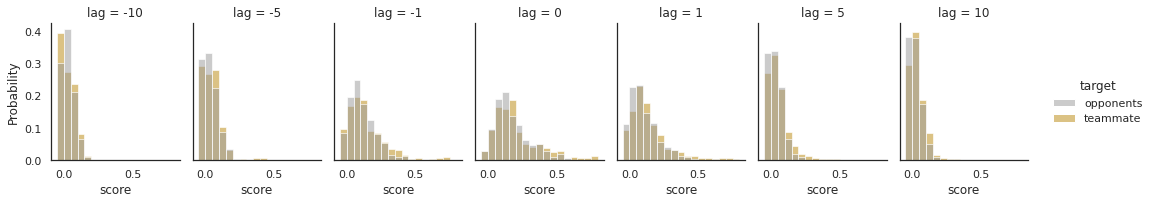

In [525]:
player_label = 'lstms'
#scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['.6', 'darkgoldenrod'])
sns.displot(x='score', hue='target', stat='probability', col='lag', common_norm=False,
            binwidth=0.05, binrange=(-.05, 0.8), height=3, aspect=.7, palette=palette,
            data=scores_df, hue_order=['opponents', 'teammate'])
ax.set_xlabel('prediction performance (r)')
ax.set_ylabel('proportion of LSTM PCs')
ax.set_title('decoding teammate/opponent LSTMs')
sns.despine()

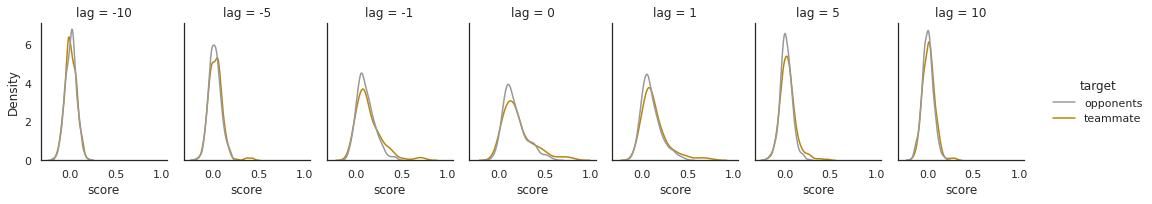

In [528]:
player_label = 'lstms'
#scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['.6', 'darkgoldenrod'])
sns.displot(x='score', hue='target', kind='kde', col='lag', common_norm=False,
            height=3, aspect=.7, palette=palette,
            data=scores_df, hue_order=['opponents', 'teammate'])
ax.set_xlabel('prediction performance (r)')
ax.set_ylabel('proportion of LSTM PCs')
ax.set_title('decoding teammate/opponent LSTMs')
sns.despine()

In [18]:
reward = wrap_f[f'map/matchup/repeat/player/time/reward'][0, 0, 0].astype(np.float32)
events = wrap_f[f'map/matchup/repeat/player/time/events'][0, 0, 0]
colors = wrap_f['map/matchup/repeat/player/color_id'][0, 0, 0] # red = 0, blue = 1
blue = wrap_f[f'map/matchup/repeat/time/blue_team_score'][0, 0, 0]
red = wrap_f[f'map/matchup/repeat/time/red_team_score'][0, 0, 0]
print(reward.shape)
print(colors)

(4, 4501, 1)
[[1]
 [1]
 [0]
 [0]]


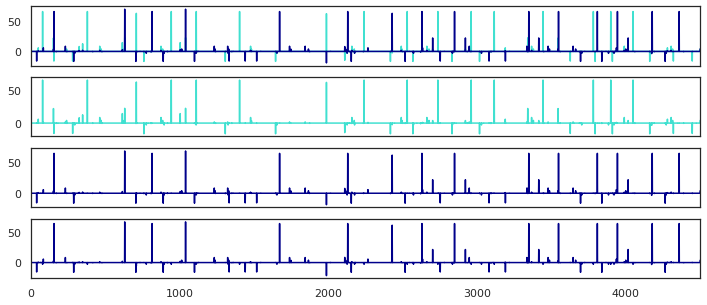

In [47]:
fig, axs = plt.subplots(4, 1, figsize=(12, 5), sharex=True)
axs[0].plot(reward[0, :], c='turquoise')
axs[0].plot(reward[1, :], c='darkblue')
axs[0].set_xlim((0, 4501))
axs[1].plot(reward[0, :], c='turquoise')
axs[2].plot(reward[1, :], c='darkblue')
axs[3].plot(resid, c='darkblue')

In [ ]:
# sum shaping rewards based on events to verify, then omit shared (TEAM) rewards

In [8]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'value'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id]
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': []}
for player_id in [0]:
    
    targets = {'player': player_stack[player_id],
               'teammate': player_stack[player_teammate[player_id]],
               'opponents': player_stack[player_opponents[player_id]]}
    
    for target_label in targets.keys():
        if target_label is not 'opponents':
            target_stack = np.expand_dims(targets[target_label], axis=0)
        else:
            target_stack = targets[target_label]
        for target in target_stack:
            for lag in lags.keys():
                scores = teammate_decoding(lstms_stack[player_id], target,
                                           lag=lag, n_splits=n_splits)
                lag_scores['score'].extend(np.mean(scores, axis=1))
                lag_scores['lag'].extend([lags[lag]] * n_splits)
                lag_scores['fold'].extend(np.arange(n_splits))
                lag_scores['target'].extend([target_label] * n_splits)
                lag_scores['player'].extend([player_id] * n_splits)
                print(f"player {player_id} {target_label} prediction "
                      f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

Finished fold 0
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 6
Finished fold 7
Finished fold 8
Finished fold 9
Finished fold 10
Finished fold 11
Finished fold 12
Finished fold 13
Finished fold 14
Finished fold 15
Finished fold 16
Finished fold 17
Finished fold 18
Finished fold 19
Finished fold 20
Finished fold 21
Finished fold 22
Finished fold 23
Finished fold 24
Finished fold 25
Finished fold 26
Finished fold 27
Finished fold 28
Finished fold 29
Finished fold 30
Finished fold 31
player 0 player prediction lag 150 r = 0.176
Finished fold 0
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 6
Finished fold 7
Finished fold 8
Finished fold 9
Finished fold 10
Finished fold 11
Finished fold 12
Finished fold 13
Finished fold 14
Finished fold 15
Finished fold 16
Finished fold 17
Finished fold 18
Finished fold 19
Finished fold 20
Finished fold 21
Finished fold 22
Finished fold 23
Finished fold 24
Finish

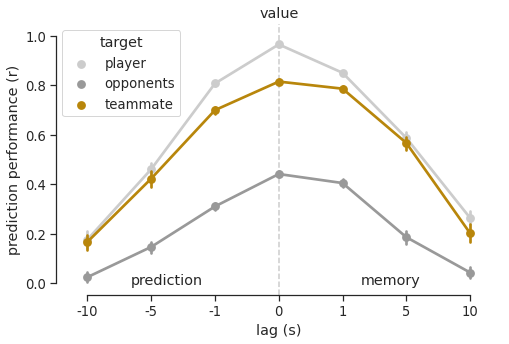

In [67]:
player_label = 'value'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

sns.set(style='ticks', font_scale=1.2)
palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate']) 
ax.set(xlabel='lag (s)', ylabel='prediction performance (r)',
       title='value', ylim=(-.05, 1.05))
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
sns.despine(trim=True)
plt.savefig('figures/decoding_value.png', bbox_inches='tight', transparent=True, dpi=300)

In [28]:
def teammate_residual(own_stack, teammate_stack, n_matches=32):
    own_split = np.split(own_stack, n_matches)
    teammate_split = np.split(teammate_stack, n_matches)
    residual_stack = []
    for match_id in np.arange(n_matches):
        player_match = own_split[match_id]
        teammate_match = teammate_split[match_id]
        x = np.linalg.lstsq(player_match, teammate_match[:, 0], rcond=None)[0]
        teammate_residual = teammate_match[:, 0] - np.dot(player_match, x)
        residual_stack.append(teammate_residual)
    teammate_residuals = np.hstack(residual_stack)
    return teammate_residuals

In [32]:
map_id = slice(None)
repeat_id = 0
player_id = slice(None)

n_splits = 32

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

player_label = 'reward'
player = wrap_f[f'map/matchup/repeat/player/time/{player_label}'][map_id, matchup_id, repeat_id, player_id].astype(np.float32)
player = player[..., :2]
player_stack = np.concatenate(np.split(player, n_maps, axis=0), axis=2)[0]

# negative lags: teammate precedes player / player remembers teammate's past states
# positive lags: player precedes teammate / player predicts teammate's future states
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

lag_scores = {'score': [], 'lag': [], 'fold': [], 'target': [], 'player': []}
for player_id in [0]:
    
    teammate_residuals = teammate_residual(player_stack[player_id],
                                           player_stack[player_teammate[player_id]],
                                           n_matches=n_maps)
    
    targets = {'player': player_stack[player_id],
               'teammate': teammate_residuals[:, np.newaxis],
               'opponents': player_stack[player_opponents[player_id]]}
    
    for target_label in targets.keys():
        if target_label is not 'opponents':
            target_stack = np.expand_dims(targets[target_label], axis=0)
        else:
            target_stack = targets[target_label]
        for target in target_stack:
            for lag in lags.keys():
                scores = teammate_decoding(lstms_stack[player_id], target,
                                           lag=lag, n_splits=n_splits)
                lag_scores['score'].extend(np.mean(scores, axis=1))
                lag_scores['lag'].extend([lags[lag]] * n_splits)
                lag_scores['fold'].extend(np.arange(n_splits))
                lag_scores['target'].extend([target_label] * n_splits)
                lag_scores['player'].extend([player_id] * n_splits)
                print(f"player {player_id} {target_label} prediction "
                      f"lag {lag} r = {np.mean(scores):.3f}")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv', index=False)

Finished fold 0
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 6
Finished fold 7
Finished fold 8
Finished fold 9
Finished fold 10
Finished fold 11
Finished fold 12
Finished fold 13
Finished fold 14
Finished fold 15
Finished fold 16
Finished fold 17
Finished fold 18
Finished fold 19
Finished fold 20
Finished fold 21
Finished fold 22
Finished fold 23
Finished fold 24
Finished fold 25
Finished fold 26
Finished fold 27
Finished fold 28
Finished fold 29
Finished fold 30
Finished fold 31
player 0 player prediction lag 150 r = 0.007
Finished fold 0
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 6
Finished fold 7
Finished fold 8
Finished fold 9
Finished fold 10
Finished fold 11
Finished fold 12
Finished fold 13
Finished fold 14
Finished fold 15
Finished fold 16
Finished fold 17
Finished fold 18
Finished fold 19
Finished fold 20
Finished fold 21
Finished fold 22
Finished fold 23
Finished fold 24
Finish

In [ ]:
# check if reward is predictable at t = 1

In [ ]:
# worth checking t -1 and t +1

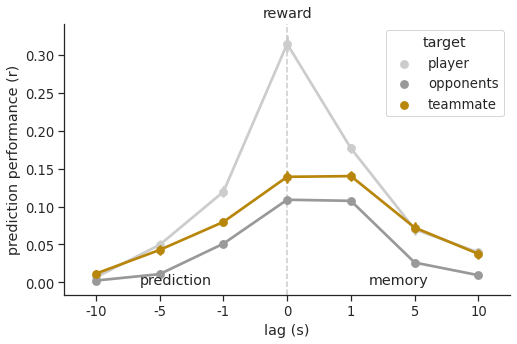

In [66]:
player_label = 'reward'
scores_df = pd.read_csv(f'results/decoding_{player_label}_matchup-{matchup_id}_results.csv')

palette = sns.color_palette(['.8', '.6', 'darkgoldenrod'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(x='lag', y='score', hue='target', data=scores_df,
              ax=ax, palette=palette,
              hue_order=['player', 'opponents', 'teammate'])
ax.set_xlabel('lag (s)')
ax.set_ylabel('prediction performance (r)')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
ax.set_title(player_label)
sns.despine()
plt.savefig('figures/decoding_reward.png', bbox_inches='tight', transparent=True, dpi=300)